<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">Produisez une étude de marché avec Python 2/2</h1>
</div>

<b><u>NOTEBOOK 2</u></b>

Réaliser une ACP avec réductions des dimensions et un clustering (dans un notebook séparé de l’exploration des données) :

o	Analyse le cercle des corrélations et la projection des individus. 

o	Regroupe les pays en utilisant les données de ton ACP ou les données brutes. 

o	Commence par la classification ascendante hiérarchique puis un k-means. 

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans

In [5]:
df = pd.read_csv("df_complet.csv", sep=";")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - ACP : Analyse par composantes principales</h2>
</div>

df = base avec plusieurs variables par pays (PIB, croissance, stabilité, etc.). L’ACP sert à :
- Réduire le nombre de variables tout en gardant l’essentiel de l’information.
- Identifier des profils de pays selon des combinaisons de variables.
- Visualiser les pays dans un espace simplifié (2 ou 3 dimensions)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Préparation des données</h3>
</div>

L’ACP ne peut travailler que sur des variables numériques et comparables. On commence donc par :
- Retirer les colonnes non numériques (Country Name, Country Code)
- Standardiser les variables (moyenne = 0, écart-type = 1) pour que toutes aient le même poids.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    119 non-null    object 
 1   Country Code    119 non-null    object 
 2   population      119 non-null    int64  
 3   pib             119 non-null    float64
 4   croissance      119 non-null    float64
 5   export          119 non-null    float64
 6   import          119 non-null    float64
 7   production      119 non-null    float64
 8   stabilité       119 non-null    float64
 9   urbanisation    119 non-null    float64
 10  doing business  119 non-null    float64
 11  distance        119 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 11.3+ KB


In [11]:
# Retrait colonnes non numériques
X = df.drop(columns=["Country Name", "Country Code"])

# Normalisation : chaque variable aura moyenne 0 et écart-type 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# Lancement de l'ACP
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Standardisation des données</h3>
</div>

Cnsiste à transformer les variables pour qu’elles aient toutes la même échelle, ce qui est crucial pour les méthodes comme l’ACP, la régression ou le clustering. Voici ce que cela implique concrètement :

Objectif :
Mettre toutes les variables sur un pied d’égalité, en supprimant l’influence de leur unité ou de leur ordre de grandeur.

Pourquoi :
- Une variable comme le PIB (en milliards) pourrait dominer l’analyse simplement parce qu’elle a des valeurs plus grandes.
- L’ACP cherche à maximiser la variance : sans standardisation, elle privilégierait les variables les plus “volatiles” en valeur absolue.
- Cela permet de comparer des pommes et des oranges… sans que les oranges écrasent tout.

La standardisation, c’est comme mettre toutes les variables sur la même échelle
Exemple avec :
- le PIB d’un pays (en milliards)
- son taux de croissance (en pourcentage)
- sa distance (en kilomètres)

Ces chiffres n’ont rien à voir en termes de grandeur. Si tu les utilises tels quels, le PIB va écraser les autres dans l’analyse, simplement parce qu’il est plus grand.

Solution : on transforme chaque variable pour qu’elle ait
- une moyenne de 0 → ça centre les données
- un écart-type de 1 → ça les met à la même “largeur”

Concrètement
Pour chaque valeur dans une colonne :
- on soustrait la moyenne de la colonne → ça la centre
- on divise par l’écart-type → ça la met à la même échelle
C’est ce que fait StandardScaler() dans scikit-learn.

Pourquoi c’est utile ?
- L’ACP cherche à capter la variabilité des données.
- Si une variable a des valeurs plus grandes, elle va dominer l’analyse.
- Standardiser permet à toutes les variables de contribuer équitablement.


In [15]:
# Sélection des variables numériques
variables = ['population', 'pib', 'croissance', 'export', 'import', 'production',
             'stabilité', 'urbanisation', 'doing business', 'distance']
X = df[variables]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Création des composantes principales et cercle de corrélation</h3>
</div>

L’ACP permet de réduire le nombre de dimensions tout en conservant l’essentiel de l’information. Elle crée de nouvelles variables (appelées composantes principales) qui résument les données.

Etape :

1/ Déterminer le nb de composantes principales à garder pour l'ACP -> éboulis avec variance par composante. Ici Les 2 premières CP captent un peu plus de 50% de l'info total

2/ Demander à l’ACP de créer 2 composantes principales. Ces axes sont des combinaisons des variables initiales, choisis pour maximiser la variance.

In [18]:
# ACP sur toutes les composantes
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

# Variance expliquée
explained_var = pca_full.explained_variance_ratio_

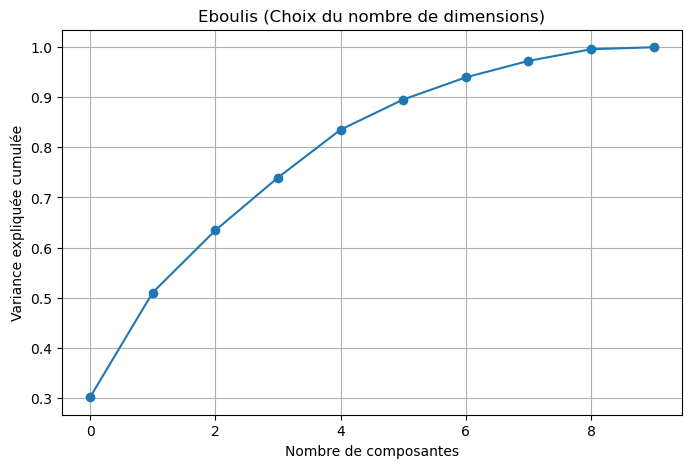

In [19]:
# Pour savoir combien de composantes garder
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Eboulis (Choix du nombre de dimensions)")
plt.grid(True)
plt.show()

In [20]:
# ACP avec 2 composantes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Cercle de corrélation

Le cercle de corrélation montre comment chaque variable est liée aux deux axes principaux. C’est une façon de visualiser les contributions des variables à l’ACP.

Etape :
On trace les flèches représentant chaque variable dans le plan des deux composantes. Plus une flèche est longue et proche du cercle, plus la variable est bien représentée


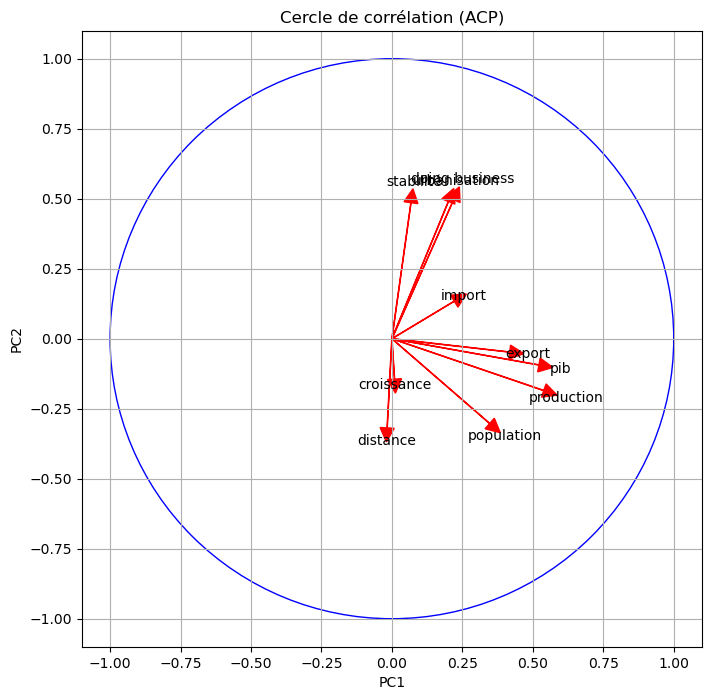

In [22]:
# Cercle de corrélation
fig, ax = plt.subplots(figsize=(8, 8))

# Vecteurs des variables dans le nouvel espace
for i, var in enumerate(variables):
    ax.arrow(0, 0, 
             pca.components_[0, i], 
             pca.components_[1, i], 
             head_width=0.05, head_length=0.05, fc='red', ec='red')
    ax.text(pca.components_[0, i]*1.15, 
            pca.components_[1, i]*1.15, 
            var, color='black', ha='center', va='center')

# Cercle unité
circle = plt.Circle((0, 0), 1, color='blue', fill=False)
ax.add_artist(circle)

# Paramètres du graphique
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Cercle de corrélation (ACP)')
ax.grid()
plt.show()

Interprétation des axes principaux

1/ Axe PC1 : Dimension économique
Les variables fortement corrélées à PC1 sont :
- pib
- production
- export
- import
- population

2/ Axe PC2 : Dimension accessibilité et potentiel commercial
Les variables corrélées à PC2 sont :
- stabilité
- urbanisation
- indice doing business
variables qui reflètent des aspects structurels et institutionnels : qualité de vie, gouvernance, attractivité pour les entreprises

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.4 - Projection des individus (pays)</h3>
</div>

Sert à voir comment les pays se répartissent dans l’espace des deux composantes. Cela permet de détecter des groupes naturels ou des profils similaires.

Etape :
On projette chaque pays dans le plan factoriel et on ajoute son code pays pour l’identifier

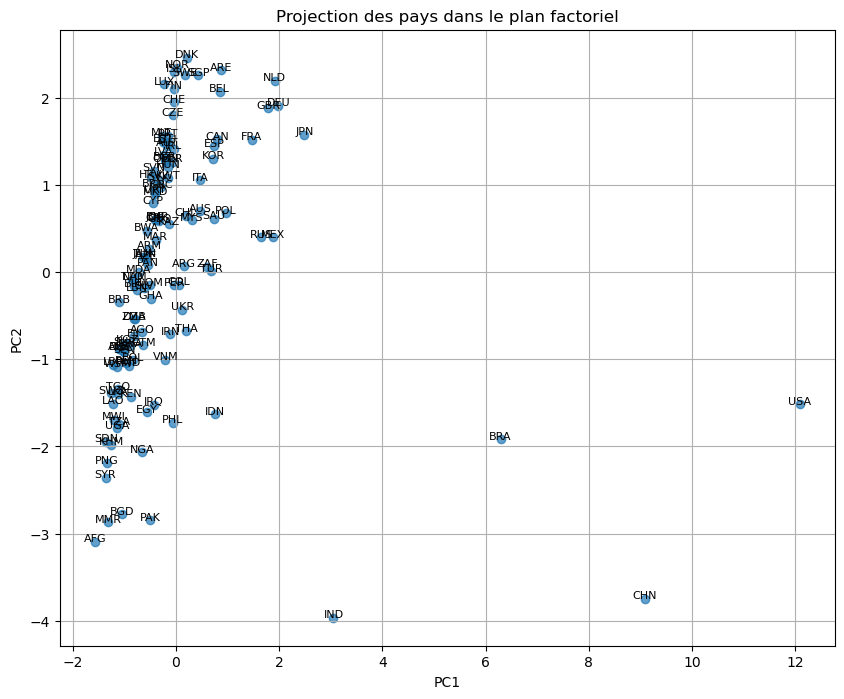

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7)

for i in range(len(df)):
    ax.text(X_pca[i, 0], X_pca[i, 1], df['Country Code'][i], fontsize=8, ha='center')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Projection des pays dans le plan factoriel')
ax.grid()
plt.show()

Interpretation
Chaque point est un pays, positionné selon ses scores sur :
- PC1 (axe horizontal) → dimension économique (pib, production, export, etc.)
- PC2 (axe vertical) → dimension socio-institutionnelle (stabilité, urbanisation, doing business)


1/ Pays éloignés du centre
- USA, CHN, IND : très éloignés → profils atypiques ou extrêmes
- USA : probablement très haut sur PC1 (puissance économique)
- CHN : forte production/export, mais peut-être plus modéré sur PC2
- IND : forte population, mais peut-être moins favorable sur doing business ou stabilité
Ces pays ont des profils distincts qui les différencient nettement du reste du panel.

2/ Pays proches du centre
- Regroupement dense autour de l’origine → pays aux profils moyens ou équilibrés
- Ils n’ont pas de caractéristiques extrêmes sur les deux axes
- Ce sont souvent des pays “intermédiaires” ou “moyennement développés”

3/ Pays dans un quadrant spécifique
- Par exemple, un pays en haut à droite → économiquement fort + institutionnellement stable
- En bas à gauche → faible économie + faible gouvernance

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - CAH : Classification Ascendante Hiérarchique</h2>
</div>

Méthode de regroupement (clustering) qui permet de former des groupes de pays similaires en fonction de leurs caractéristiques. Elle ne nécessite pas de fixer le nombre de groupes à l’avance : on peut le choisir en regardant le dendrogramme.

Ce qui est fait :
- Calcul des distances (distances mathématiques et non distance km du df) entre les pays (sur les données standardisées).
- Regroupement des pays les plus proches, étape par étape.
- Visualisation du résultat sous forme de dendrogramme (arbre de regroupement).
- Choix du nombre de groupes (par exemple 4) en coupant l’arbre à une certaine hauteur.

In [30]:
#fonction nécessaire
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [31]:
# Lien entre les pays selon leurs coordonnées dans le plan factoriel
Z = linkage(X_pca, method='ward')

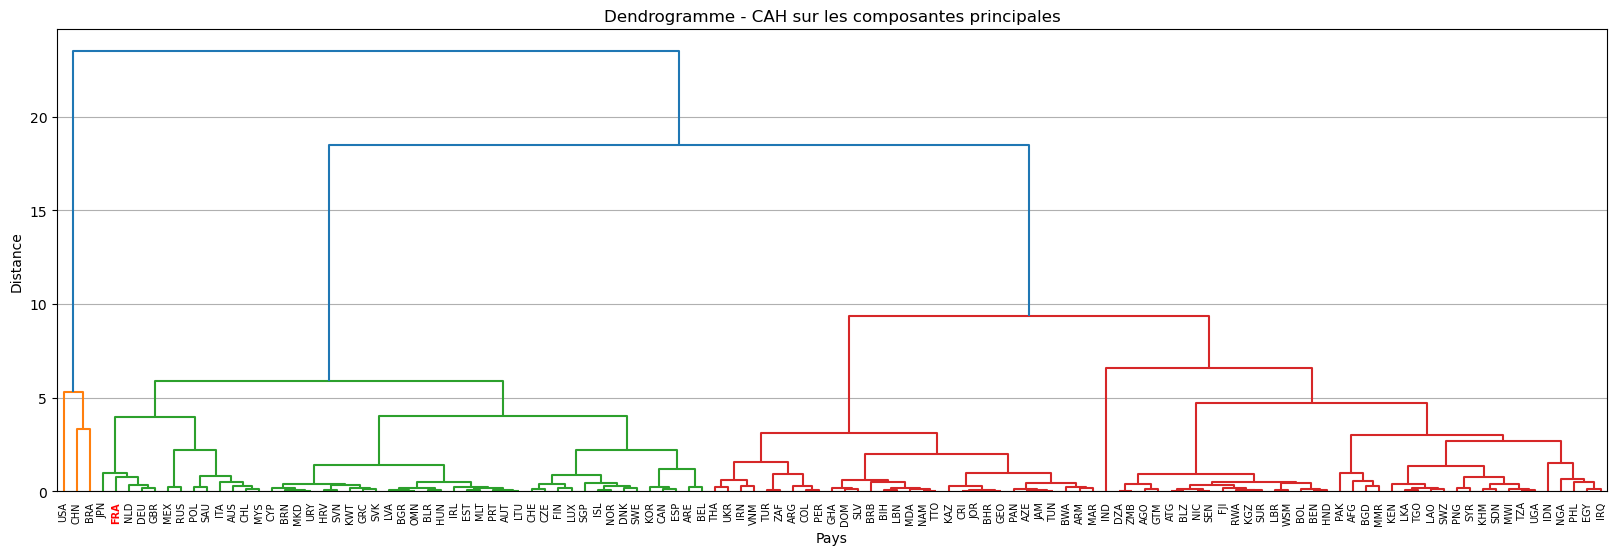

In [32]:
#Dendrogramme
plt.figure(figsize=(20, 6))
ddata = dendrogram(Z, labels=df['Country Code'].values, leaf_rotation=90)

# Titre et axes
plt.title('Dendrogramme - CAH sur les composantes principales')
plt.xlabel('Pays')
plt.ylabel('Distance')
plt.grid(axis='y')
plt.xticks(fontsize=7)

# Surlignage de 'FRA'
labels = ddata['ivl']  # Liste des labels dans l'ordre d'affichage
tick_locs = plt.xticks()[0]  # Positions des ticks sur l'axe X

# Trouver la position de 'FRA'
if 'FRA' in labels:
    idx = labels.index('FRA')
    plt.xticks(tick_locs, labels)  # Réaffecter les labels pour garder l'ordre
    plt.gca().get_xticklabels()[idx].set_color('red')
    plt.gca().get_xticklabels()[idx].set_fontweight('bold')

plt.show()


- 4 grands groupes (rouge x2, vert, orange).
- La hauteur des branches représente la distance (ou dissimilarité) entre les groupes : plus la fusion est haute, plus les groupes sont différents.

In [34]:
# visualisation 4 groupes pour future comparaison avec le k-means
df['cluster_cah'] = fcluster(Z, t=4, criterion='maxclust')

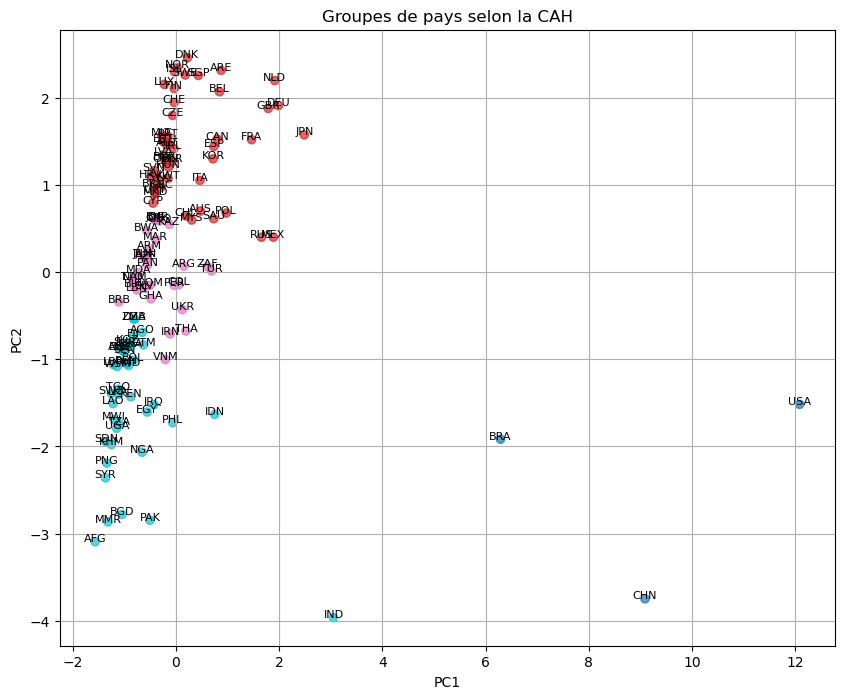

In [35]:
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_cah'], cmap='tab10', alpha=0.7)

for i in range(len(df)):
    plt.text(X_pca[i, 0], X_pca[i, 1], df['Country Code'][i], fontsize=8, ha='center')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Groupes de pays selon la CAH')
plt.grid()
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Clustering K-means sur les composantes principales</h2>
</div>

Le K-means est un algorithme de clustering non supervisé qui sert à :

Regrouper des individus (ici, des pays) en k groupes homogènes
- Chaque groupe contient des pays similaires entre eux selon les variables que tu as choisies (ou les composantes principales de ton ACP).
- L’objectif est de minimiser la variance intra-groupe (les pays d’un même groupe sont proches du centre du groupe).

Identifier des profils types
- Chaque cluster représente un profil synthétique : par exemple, “économies avancées”, “pays émergents”, “profils institutionnels stables”, etc.
- Tu peux ensuite caractériser chaque groupe en calculant les moyennes des variables.

Optimiser la segmentation
- Contrairement à la CAH, le K-means cherche à optimiser mathématiquement la qualité des regroupements.

Evaluer cette qualité via :
- Inertie intra-classe : compacité des groupes
- Inertie inter-classe : séparation entre groupes
- Ratio inter/intra : indicateur de performance

In [38]:
from sklearn.cluster import KMeans

C:\Users\t_rak\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\t_rak\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\t_rak\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\t_rak\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\t_rak\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(e

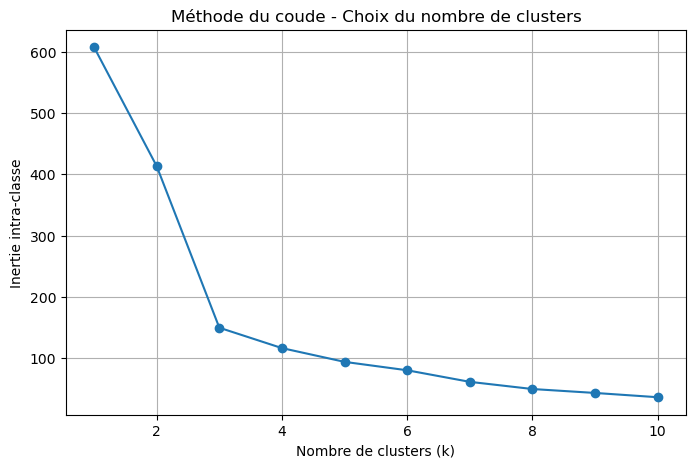

In [39]:
inerties = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inerties.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inerties, marker='o')
plt.title("Méthode du coude - Choix du nombre de clusters")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie intra-classe")
plt.grid()
plt.show()

In [40]:
#K-means Choix du nb de clusters = 3 car la courbe s'aplatit
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)
df['cluster_kmeans'] = labels_kmeans

C:\Users\t_rak\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


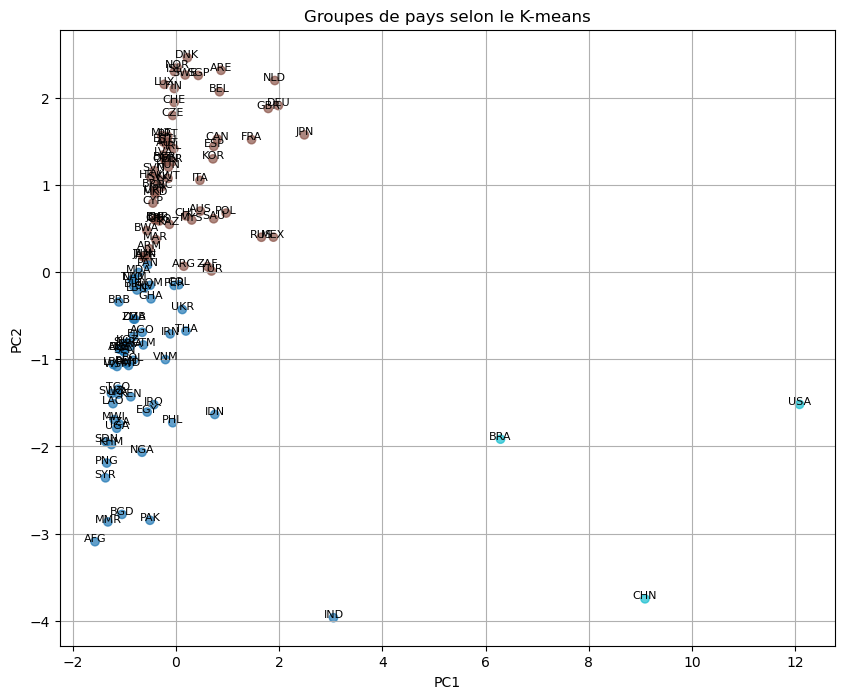

In [41]:
#Visualisation dans le plan factoriel
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'], cmap='tab10', alpha=0.7)

for i in range(len(df)):
    plt.text(X_pca[i, 0], X_pca[i, 1], df['Country Code'][i], fontsize=8, ha='center')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Groupes de pays selon le K-means')
plt.grid()
plt.show()

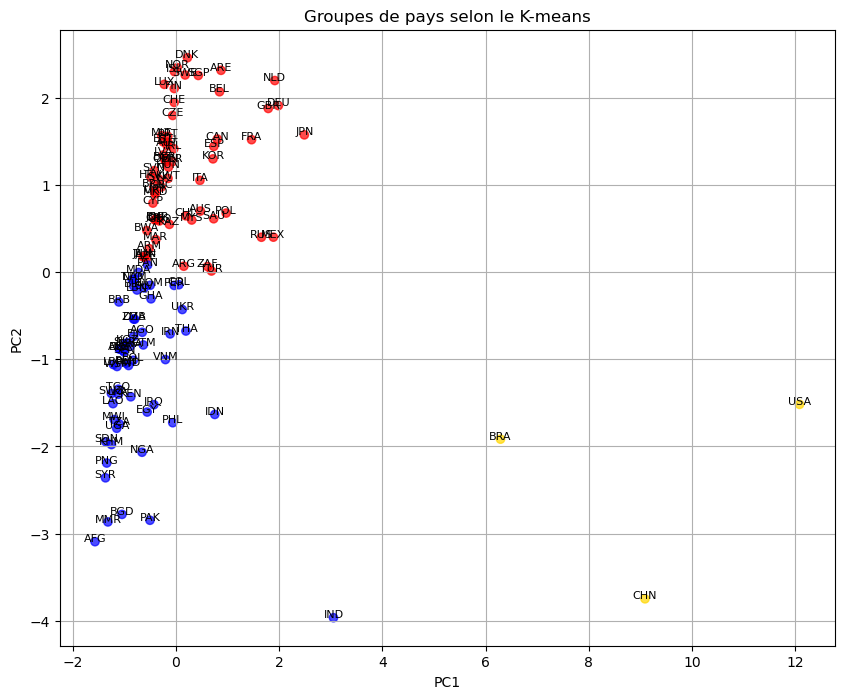

In [42]:
#Même graphique couleurs contrastées
import matplotlib.pyplot as plt

# Définir les couleurs manuellement pour chaque cluster
cluster_colors = {0: 'blue', 1: 'red', 2: 'gold'}  # or 'yellow' if you prefer

# Appliquer les couleurs à chaque point
colors = df['cluster_kmeans'].map(cluster_colors)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.7)

# Ajouter les codes pays
for i in range(len(df)):
    plt.text(X_pca[i, 0], X_pca[i, 1], df['Country Code'][i], fontsize=8, ha='center')

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Groupes de pays selon le K-means')
plt.grid()
plt.show()

In [43]:
#calcul inertie INTRA classes
inertie_intra = kmeans.inertia_
print(f"Inertie intra-classe : {inertie_intra:.2f}")

Inertie intra-classe : 149.56


donne une mesure quantitative de la compacité des groupes formés par ton K-means.

signification :
• 	L’inertie intra-classe = somme des distances au carré entre chaque pays et le centre de son cluster.
• 	Plus cette valeur est faible, plus les pays sont proches de leur centroïde, donc plus les groupes sont homogènes.
• 	pour k=4, la dispersion moyenne dans les groupes est modérée
• 	ne dit rien sur la qualité globale du clustering sans la comparer à l’inertie inter-classe.


In [45]:
#calcul inertie INTER classes et ration INTER/INTRA
global_center = np.mean(X_pca, axis=0)
cluster_centers = kmeans.cluster_centers_
cluster_sizes = np.bincount(labels_kmeans)

inertie_inter = sum(
    cluster_sizes[i] * np.sum((cluster_centers[i] - global_center)**2)
    for i in range(len(cluster_centers))
)

print(f"Inertie inter-classe : {inertie_inter:.2f}")
print(f"Rapport inter/intra : {inertie_inter / inertie_intra:.2f}")

Inertie inter-classe : 457.58
Rapport inter/intra : 3.06


Interprétation du ratio :
<1 : Groupes peu distincts, clustering peu structurant.
≈ 1–2 : Groupes modérément séparés, segmentation acceptable.
'>2 : Groupes bien distincts, clustering robuste.
'>4 : Excellente séparation entre les groupes.

Le ratio de 3 indique que :
- Les groupes sont ien séparés dans l’espace des composantes principales.
- Le K-means a réussi à regrouper les pays de manière cohérente, avec des centres de clusters éloignés les uns des autres.
- L’inertie intra-classe est maîtrisée (groupes compacts), et l’inertie inter-classe est élevée (groupes éloignés).

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse des groupes issus de la CAH et du K-means</h2>
</div>

In [48]:
#rappel df principal avec colonne cluster_cah et colonne cluster_kmeans
df

,Country Name,Country Code,population,pib,croissance,export,import,production,stabilité,urbanisation,doing business,distance,cluster_cah,cluster_kmeans
0,China,CHN,1402760000,1.414777e+13,6.756718,177284.51,502221.09,14583728.12,-0.298572,59.152,73.30366,8225.232,1,2
1,Afghanistan,AFG,36743039,1.805322e+10,1.189228,154.00,23913.00,29315.76,-2.753441,25.495,44.20343,5590.381,4,0
2,Angola,AGO,31297155,7.945069e+10,-1.316362,34.90,322679.69,41476.19,-0.347209,65.514,41.20205,6510.322,4,0
3,United Arab Emirates,ARE,9346701,4.270494e+11,1.313914,36433.62,591186.03,47271.00,0.689256,86.522,81.58883,5249.535,2,1
4,Argentina,ARG,44654882,5.248199e+11,-2.617396,162443.43,6623.56,2068494.00,0.006910,91.870,58.18388,11072.250,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,United States,USA,328529577,2.065652e+13,2.966505,3305142.55,63960.46,19568042.00,0.386239,82.256,83.57395,5838.157,1,2
115,Viet Nam,VNM,96237319,3.101065e+11,7.465007,21721.96,172807.47,839573.47,0.033083,35.919,68.56869,9208.554,3,0
116,Samoa,WSM,207582,8.784484e+08,-0.609647,42.60,16640.38,379.29,1.133752,18.243,62.06781,16011.920,4,0
117,South Africa,ZAF,58613001,4.052607e+11,1.556784,45029.23,487157.13,1743285.00,-0.237547,66.355,66.69548,9353.552,3,1


In [49]:
#affichage des nb au format classique (non scientifique)
pd.set_option('display.float_format', '{:.2f}'.format)

In [50]:
df.columns

Index(['Country Name', 'Country Code', 'population', 'pib', 'croissance',
       'export', 'import', 'production', 'stabilité', 'urbanisation',
       'doing business', 'distance', 'cluster_cah', 'cluster_kmeans'],
      dtype='object')

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.1 - Analyse des clusters de la CAH</h3>
</div>

In [52]:
#Analyse des profils moyens des clusters de la CAH
df.groupby('cluster_cah')[variables].mean().round(2)

,population,pib,croissance,export,import,production,stabilité,urbanisation,doing business,distance
cluster_cah,,,,,,,,,,
1,645798946.00,12240405223658.25,3.84,2435042.87,189859.22,15887839.92,-0.12,75.99,71.82,7823.93
2,24229681.43,754719743370.15,2.93,105488.03,140066.80,624017.34,0.64,78.37,76.10,3581.82
3,24595202.37,153095748784.01,2.72,46894.25,56565.28,594344.91,-0.32,65.46,67.24,5927.46
4,78731705.59,172273238862.06,3.74,960.07,39077.36,409011.01,-0.67,41.10,55.50,7517.64


In [53]:
for i in sorted(df['cluster_cah'].unique()):
    pays_du_cluster = df[df['cluster_cah'] == i]['Country Name'].tolist()
    print(f"Cluster CAH {i} ({len(pays_du_cluster)} pays) :")
    print(", ".join(pays_du_cluster))
    print("-" * 80)

Cluster CAH 1 (3 pays) :
China, Brazil, United States
--------------------------------------------------------------------------------
Cluster CAH 2 (47 pays) :
United Arab Emirates, Australia, Austria, Belgium, Bulgaria, Belarus, Brunei Darussalam, Canada, Switzerland, Chile, Cyprus, Czechia, Germany, Denmark, Spain, Estonia, Finland, France, United Kingdom, Greece, Croatia, Hungary, Ireland, Iceland, Italy, Japan, Korea, Rep., Kuwait, Lithuania, Luxembourg, Latvia, Mexico, North Macedonia, Malta, Malaysia, Netherlands, Norway, Oman, Poland, Portugal, Russian Federation, Saudi Arabia, Singapore, Slovak Republic, Slovenia, Sweden, Uruguay
--------------------------------------------------------------------------------
Cluster CAH 3 (30 pays) :
Argentina, Armenia, Azerbaijan, Bahrain, Bosnia and Herzegovina, Barbados, Botswana, Colombia, Costa Rica, Dominican Republic, Georgia, Ghana, Iran, Islamic Rep., Jamaica, Jordan, Kazakhstan, Lebanon, Morocco, Moldova, Namibia, Panama, Peru, El S

## Synthèse des clusters (CAH)

### Cluster 1 – Grands marchés développés et éloignés
**Profil :**  
- Population très élevée (~646 M)  
- PIB extrêmement fort → économies majeures  
- Exportations et production très élevées  
- Importations également importantes (marchés ouverts)  
- Urbanisation et Doing Business élevés (~76 et ~72)  
- Stabilité moyenne (-0.12)  
- Distance très élevée (~7800 km)  

**Interprétation :**  
Ce cluster regroupe probablement les grandes puissances économiques éloignées (ex : États-Unis, Chine, Japon).  
- Avantage : marché vaste, pouvoir d’achat élevé.  
- Inconvénient : forte production locale et concurrence importante, coûts logistiques élevés.  
- Position stratégique : opportunités de niche, à cibler via partenariats ou produits différenciés.

---

### Cluster 2 – Marchés proches et stables
**Profil :**  
- Population moyenne (~242 M)  
- PIB intermédiaire  
- Croissance modérée (~2.9 %)  
- Export/import moyens  
- Stabilité forte (0.64)  
- Urbanisation et Doing Business élevés (~78)  
- Distance relativement faible (~3600 km)  

**Interprétation :**  
Il s’agit de marchés accessibles, stables et en développement — probablement des pays du Maghreb, du Moyen-Orient ou d’Europe de l’Est.  
- Avantage : proximité géographique, environnement favorable aux affaires, stabilité.  
- Inconvénient : taille économique moyenne.  
- Position stratégique : **cible prioritaire pour l’export de volaille**

---

### Cluster 3 – Marchés intermédiaires éloignés et instables
**Profil :**  
- Population similaire au cluster 2 (~246 M)  
- PIB plus faible (~1.53e13)  
- Croissance modérée (~2.7 %)  
- Export/import faibles  
- Stabilité négative (-0.32)  
- Urbanisation moyenne (~65 %)  
- Doing Business correct (~67)  
- Distance importante (~5900 km)  

**Interprétation :**  
Ces pays sont probablement des marchés émergents éloignés (ex : Afrique subsaharienne, Asie du Sud-Est).  
- Avantage : croissance soutenue, marché en expansion.  
- Inconvénient : infrastructures limitées, instabilité, coûts de transport élevés.  
- Position stratégique : opportunités à moyen terme, à suivre selon l’évolution politique et économique.

---

### Cluster 4 – Petits marchés en difficulté et éloignés
**Profil :**  
- Population faible (~78 M)  
- PIB le plus bas  
- Croissance correcte (~3.7 %)  
- Export très faible (~960) et import modéré (~39 000)  
- Production faible  
- Stabilité négative (-0.67)  
- Urbanisation faible (~41 %)  
- Doing Business bas (~55)  
- Distance élevée (~7500 km)  

**Interprétation :**  
Ce cluster regroupe de petits marchés fragiles économiquement et institutionnellement.  
- Avantage : croissance potentielle, besoins alimentaires.  
- Inconvénient : faible pouvoir d’achat, risques politiques/logistiques.  
- Position stratégique : marchés à faible priorité, à aborder via aide, coopération ou export indirect.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.2 - Analyse des clusters K-means</h3>
</div>

In [56]:
df.groupby('cluster_kmeans')[variables].mean().round(2)

,population,pib,croissance,export,import,production,stabilité,urbanisation,doing business,distance
cluster_kmeans,,,,,,,,,,
0,63972758.69,163591158709.21,3.46,13629.08,41406.23,477811.20,-0.58,46.95,58.17,7190.02
1,23421080.13,619440048992.32,2.87,92665.71,123389.72,603786.49,0.43,76.52,74.74,3998.46
2,645798946.00,12240405223658.25,3.84,2435042.87,189859.22,15887839.92,-0.12,75.99,71.82,7823.93


In [57]:
for i in sorted(df['cluster_kmeans'].unique()):
    pays_du_cluster = df[df['cluster_kmeans'] == i]['Country Name'].tolist()
    print(f"Cluster kmeans {i} ({len(pays_du_cluster)} pays) :")
    print(", ".join(pays_du_cluster))
    print("-" * 80)

Cluster kmeans 0 (55 pays) :
Afghanistan, Angola, Antigua and Barbuda, Benin, Bangladesh, Bosnia and Herzegovina, Belize, Bolivia, Barbados, Colombia, Dominican Republic, Algeria, Egypt, Arab Rep., Fiji, Ghana, Guatemala, Honduras, Indonesia, India, Iran, Islamic Rep., Iraq, Kenya, Kyrgyz Republic, Cambodia, Lao PDR, Lebanon, Liberia, Sri Lanka, Moldova, Myanmar, Malawi, Namibia, Nigeria, Nicaragua, Pakistan, Panama, Peru, Philippines, Papua New Guinea, Rwanda, Sudan, Senegal, El Salvador, Suriname, Eswatini, Syrian Arab Republic, Togo, Thailand, Trinidad and Tobago, Tanzania, Uganda, Ukraine, Viet Nam, Samoa, Zambia
--------------------------------------------------------------------------------
Cluster kmeans 1 (61 pays) :
United Arab Emirates, Argentina, Armenia, Australia, Austria, Azerbaijan, Belgium, Bulgaria, Bahrain, Belarus, Brunei Darussalam, Botswana, Canada, Switzerland, Chile, Costa Rica, Cyprus, Czechia, Germany, Denmark, Spain, Estonia, Finland, France, United Kingdom, G

## Synthèse des clusters (K-means)

### Cluster 0 – Marchés intermédiaires éloignés et moyennement développés
**Profil :**  
- Population élevée (~64 M)  
- PIB moyen (~16.36e12)  
- Croissance correcte (~3.46 %)  
- Exportations faibles (~13 600)  
- Importations modérées (~41 000)  
- Production moyenne (~477 800)  
- Stabilité négative (-0.58)  
- Urbanisation faible (~47 %)  
- Doing Business modéré (~58)  
- Distance élevée (~7190 km)

**Interprétation :**  
Ce cluster regroupe des pays éloignés avec un niveau de développement intermédiaire, une stabilité faible et des échanges limités.  
- Avantage : croissance modérée, marché en expansion.  
- Inconvénient : instabilité et infrastructures limitées.  
- Position stratégique : trop éloignés, stabilité négative

---

### Cluster 1 – Marchés émergents proches et stables
**Profil :**  
- Population moyenne (~23 M)  
- PIB intermédiaire (~6.19e12)  
- Croissance modérée (~2.87 %)  
- Exportations moyennes (~92 600)  
- Importations élevées (~123 000)  
- Production moyenne (~603 800)  
- Bonne stabilité (0.43)  
- Urbanisation élevée (~77 %)  
- Doing Business élevé (~75)  
- Distance faible (~4000 km)

**Interprétation :**  
Il s’agit de marchés stables, bien connectés et proches de la France, probablement des pays du Maghreb, d’Europe de l’Est ou du Moyen-Orient.  
- Avantage : proximité géographique, stabilité politique, environnement favorable aux affaires.  
- Inconvénient : taille de marché moyenne.  
- Position stratégique : proches et stables

---

### Cluster 2 – Grands marchés développés et éloignés
**Profil :**  
- Population très élevée (~646 M)  
- PIB très élevé (~12.24e13)  
- Croissance solide (~3.84 %)  
- Exportations et importations très fortes  
- Production très élevée (~15.9e6)  
- Stabilité moyenne (-0.12)  
- Urbanisation élevée (~76 %)  
- Doing Business bon (~72)  
- Distance élevée (~7800 km)

**Interprétation :**  
Ce cluster regroupe les grandes puissances économiques mondiales, éloignées géographiquement (ex : États-Unis, Chine, Japon).  
- Avantage : forte demande et pouvoir d’achat élevé.  
- Inconvénient : forte concurrence locale, coûts logistiques élevés.  
- Position stratégique : marchés à **fort potentiel mais très compétitifs**, à cibler avec des produits différenciés ou via des accords commerciaux.



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.3 - Liste des pays retenus</h3>
</div>

In [60]:
#filtre du df sur le cluster 2 (col cluster_cah) et du cluster 0 de la col cluster_kmeans
pays_retenus = df[
    (df['cluster_cah'] == 2) & 
    (df['cluster_kmeans'] == 1)
]['Country Name'].tolist()

print(f"Pays retenus ({len(pays_retenus)}) :")
print(", ".join(pays_retenus))

Pays retenus (47) :
United Arab Emirates, Australia, Austria, Belgium, Bulgaria, Belarus, Brunei Darussalam, Canada, Switzerland, Chile, Cyprus, Czechia, Germany, Denmark, Spain, Estonia, Finland, France, United Kingdom, Greece, Croatia, Hungary, Ireland, Iceland, Italy, Japan, Korea, Rep., Kuwait, Lithuania, Luxembourg, Latvia, Mexico, North Macedonia, Malta, Malaysia, Netherlands, Norway, Oman, Poland, Portugal, Russian Federation, Saudi Arabia, Singapore, Slovak Republic, Slovenia, Sweden, Uruguay


### Sélection finale des pays retenus

La sélection croisée des clusters **CAH 2** et **K-means 0** permet d’identifier **47 pays** présentant à la fois une **stabilité institutionnelle élevée**, une **bonne performance économique**, et une **intégration logistique favorable**, la majorité étant proche géographiquement de la France.

---

### Hiérarchisation des pays retenus

1) Pays membres de l’Union européenne – proches, stables et bien intégrés (26 pays)

Austria, Belgium, Bulgaria, Croatia, Cyprus, Czechia, Denmark, Estonia, Finland, Germany, Greece, Hungary, Ireland, Italy, Latvia, Lithuania, Luxembourg, Malta, Netherlands, Poland, Portugal, Slovak Republic, Slovenia, Spain, Sweden

2) Pays hors UE mais stables, à haut revenu et historiquement liés à l’Europe (9 pays)

United Kingdom, Norway, Switzerland, Iceland, Canada, Australia, Japan, Korea, Rep., Singapore

3) Pays performants mais plus éloignés géographiquement ou institutionnellement (12)

Belarus, Brunei Darussalam, Chile, Kuwait, Malaysia, Mexico, North Macedonia, Oman, Russian Federation, Saudi Arabia, United Arab Emirates, Uruguay